In [2]:
import numpy as np 
import scipy.signal as sig
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from IPython.display import HTML
import model_functions as mf
import nolds

color = ['royalblue','orange','red','purple']
R = 47
C = 1e-6
scale_factor = C * R * 1e3
t0 = 0
tmax = 10 / scale_factor
h = 0.125e-3 / scale_factor  
N = int((tmax - t0) / h)
half = N // 2

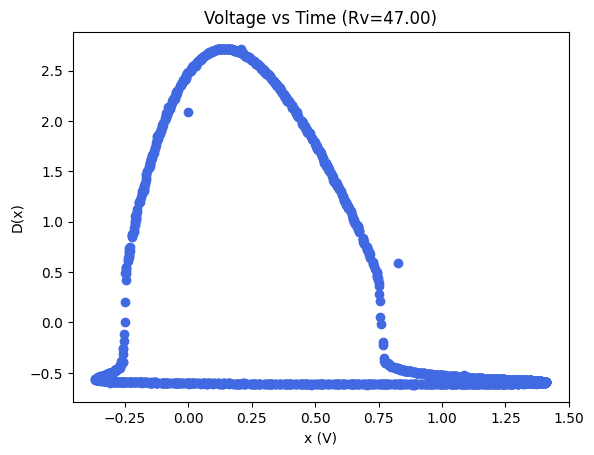

In [28]:
Rv = 47.0
data = np.loadtxt(f"../Data/RV{Rv}.txt")

plt.scatter(data[:,1],data[:,5],c='royalblue')
plt.xlabel('x (V)')
plt.ylabel("D(x)")
plt.title(rf"Voltage vs Time (Rv={Rv:.2f})")
plt.savefig('../Experimental_results/non_linear',bbox_inches = 'tight')
plt.show()

/Users/tobynguyen/Documents/physics_reports/Chaotic Pendulum/Code/model_functions.py:89: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  Phi = Phi + h * (J @ Phi)


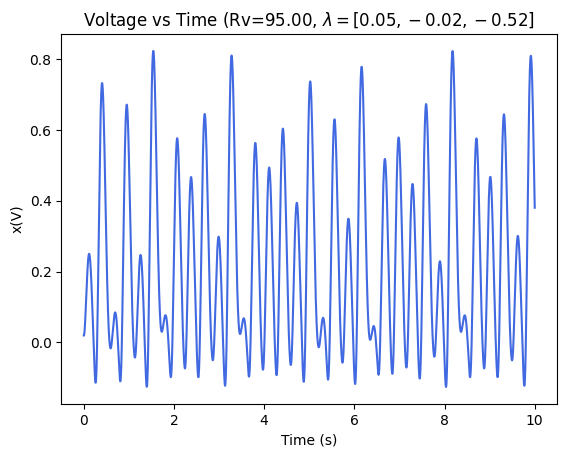

In [3]:
data = np.loadtxt("../Data/RV95.0.txt")
time,x,lambdas, lambas_inst,Rv = mf.rk4(Rv=95.0,x0=data[0][1:-2])

voltage = x[:,0]

plt.plot(time,voltage,c='royalblue')
plt.xlabel('Time (s)')
plt.ylabel("x(V)")
plt.title(rf"Voltage vs Time (Rv={Rv:.2f}, $\lambda = [{lambdas[0]:.2f}, {lambdas[1]:.2f}, {lambdas[2]:.2f}]$")
plt.savefig('../Model_Figures/static_figures/voltage_vs_time',bbox_inches = 'tight')
plt.show()

In [7]:
data = np.loadtxt("../Data/RV95.0.txt")
time,x,lambdas, lam_inst,Rv = mf.rk4(Rv=95.0,x0=data[0][1:-2])

lam0_inst = lam_inst[:, 2]  # time series of local λ1
M = lam0_inst.shape[0]
lam0_ss = lam0_inst[M//2:]

B = 10
block_size = lam0_ss.shape[0] // B
lam0_ss = lam0_ss[:B*block_size]           # trim to multiple of B
blocks = lam0_ss.reshape(B, block_size)    # shape (B, block_size)

block_means = blocks.mean(axis=1)

mean_lambda = block_means.mean()
s = block_means.std(ddof=1)        # sample standard deviation
stderr = s / np.sqrt(B)  

print("λ1 ≈ {:.6f} ± {:.6f}".format(mean_lambda, stderr))

λ1 ≈ -0.554463 ± 0.003391


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/nolds/measures.py:31: RuntimeWarning: fitting mode 'RANSAC' requires the package sklearn, using 'poly' instead
  warnings.warn(


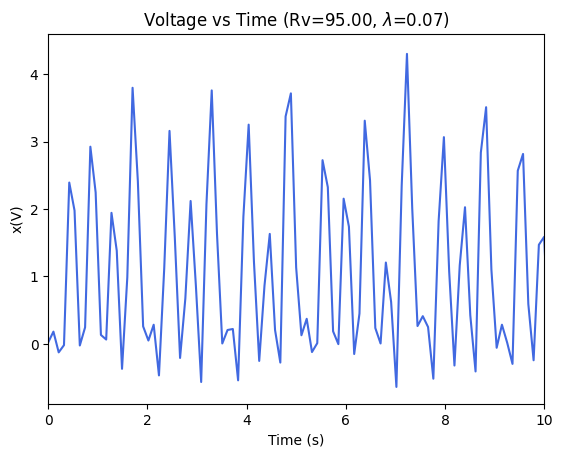

In [32]:
Rv = 95.0
data = np.loadtxt(f'../Data/RV{Rv}.txt')

t = data[:,0] / scale_factor

half = len(t) // 2

plt.xlim(0,10)

voltage = data[:,1]

lambda_exp = nolds.lyap_r(voltage[half:])

plt.plot(t,voltage,c='royalblue')
plt.xlabel('Time (s)')
plt.ylabel("x(V)")
plt.title(rf"Voltage vs Time (Rv={Rv:.2f}, $\lambda$={lambda_exp:.2f})")
plt.savefig('../Experimental_results/voltage_vs_time',bbox_inches = 'tight')
plt.show()

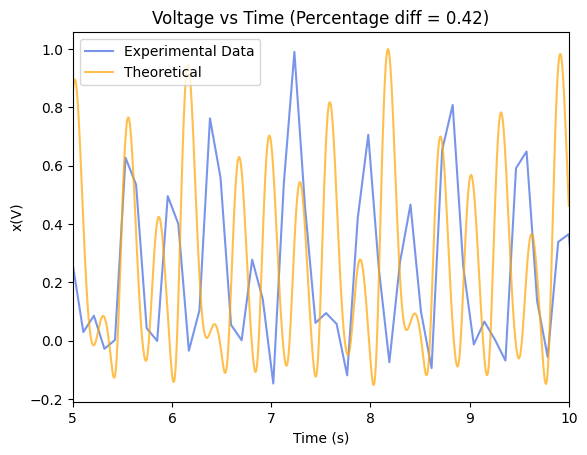

In [5]:
Rv = 95.0
data = np.loadtxt(f"../Data/RV{Rv}.txt")
time,x,lambdas, Rv = mf.rk4(Rv=95.0,x0=data[0][1:-2])

voltage_t = x[:,0] / np.max(x[:,0])
voltage_t = voltage_t[::40]
time = time[::40]
data = np.loadtxt(f'../Data/RV{Rv}.txt')

t = data[:,0] / scale_factor

plt.xlim(0,10)

voltage_exp = data[:,1] / np.max(data[:,1])

diff = voltage_exp - voltage_t

std = np.std(diff)
mean_std = np.mean(std)

plt.plot(t,voltage_exp,c='royalblue',label='Experimental Data',alpha=0.7)
plt.plot(time,voltage_t,c='orange',label='Theoretical',alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel("x(V)")
plt.title(f"Voltage vs Time (Percentage diff = {mean_std:.2f})")
plt.legend()
plt.xlim(5,10)
plt.savefig('../Experimental_results/voltage_vs_time_comparison',bbox_inches = 'tight')
plt.show()

Animation size has reached 20988707 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


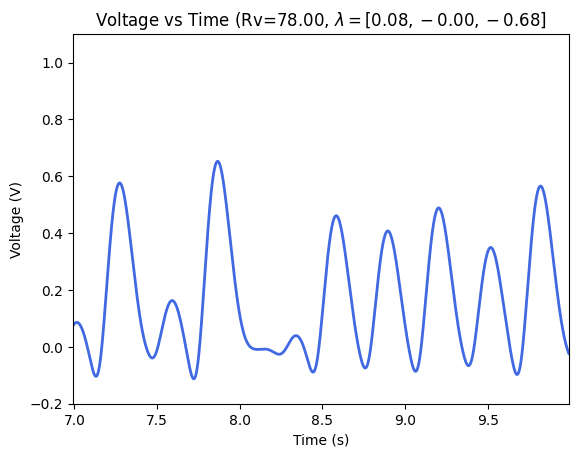

In [ ]:
t, x, lambdas, Rv = mf.rk4(Rv=78)
voltages = x[:,0]
fig, ax = plt.subplots()

ax.set_ylim(-0.2, 1.1)

ln, = plt.plot(t,voltages,lw=2,color='royalblue')
ax.set_title(rf"Voltage vs Time (Rv={Rv:.2f}, $\lambda = [{lambdas[0]:.2f}, {lambdas[1]:.2f}, {lambdas[2]:.2f}]$")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")

window_width = 3
step = 0.01

def update(frame):
    start = t[0] + frame * step
    end = start + window_width
    ax.set_xlim(start,end)
    return ln,

ani = FuncAnimation(fig, update, frames=range(0,int((t[-1]-t[0]-window_width)/step)),blit=True,interval=200)
HTML(ani.to_jshtml())
ani.save("../Model_Figures/gifs/voltage_scan_along_time.gif", writer="pillow", fps=30)

Animation size has reached 21015647 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


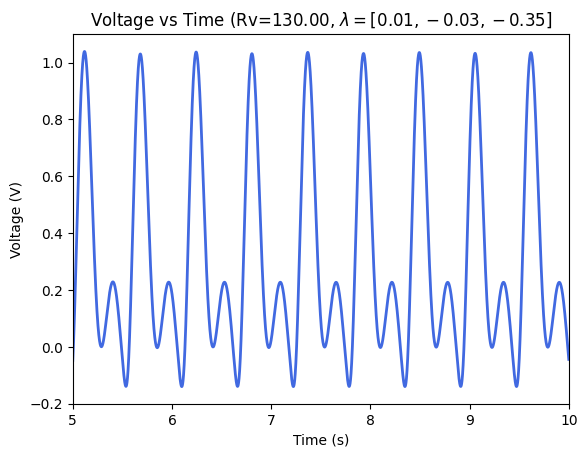

In [ ]:
fig, ax = plt.subplots()

ax.set_xlim(5, 10)
ax.set_ylim(-0.2, 1.1)

ln, = ax.plot([],[],lw=2,color='royalblue')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")

def init():
    ln.set_data([],[])
    return ln,

def update(frame):
    Rv = Rv_values[frame]

    t,x,lambdas,_ = mf.rk4(Rv=Rv)
    voltages = x[:,0]
    ln.set_data(t, voltages)
    ax.set_title(rf"Voltage vs Time (Rv={Rv:.2f}, $\lambda = [{lambdas[0]:.2f}, {lambdas[1]:.2f}, {lambdas[2]:.2f}]$")
    return ln,

Rv_values = np.linspace(50, 130, 1000)

ani = FuncAnimation(fig, update, frames=len(Rv_values),init_func=init,blit=True,interval=200)
HTML(ani.to_jshtml())
ani.save("../Model_Figures/gifs/voltage_scan_along_Rv.gif", writer="pillow", fps=20)

/Users/tobynguyen/Documents/physics_reports/Chaotic Pendulum/Code/model_functions.py:83: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  Phi = Phi + h * (J @ Phi)


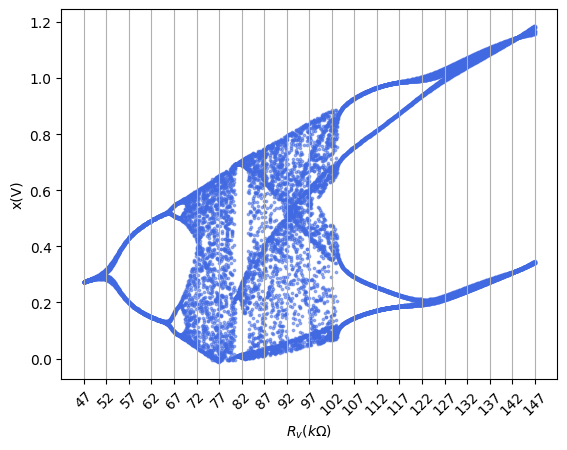

In [2]:
Rv_range = np.linspace(47,147,1000)

Rv_values = []
peaks_voltages = []

for i in Rv_range:
    time,x,_,_ = mf.rk4(Rv=i)
    voltages = x[half:,0]

    peaks_pos, _ = sig.find_peaks(voltages)
    peak_values = voltages[peaks_pos]

    Rv_values.extend([i]*len(peak_values))
    peaks_voltages.extend(peak_values)

plt.scatter(Rv_values,peaks_voltages,s=3,color=color[0],alpha=0.5)
plt.xlabel(r'$R_v(k\Omega)$')
plt.grid(axis='x')
plt.xticks(np.linspace(47, 147, 21),rotation=45)
plt.ylabel("x(V)")
plt.savefig('../Model_Figures/static_figures/bifurication_plot',bbox_inches = 'tight')

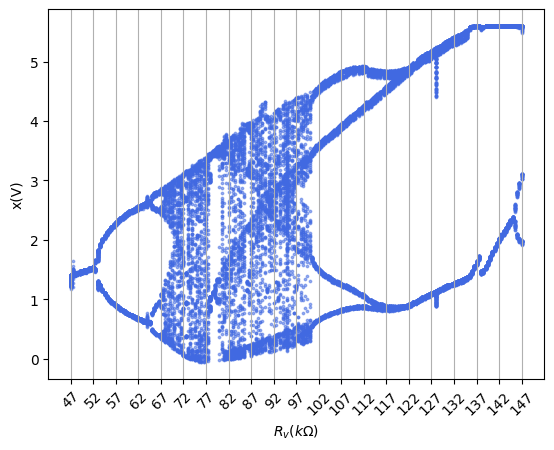

In [4]:
Rv_range = np.linspace(47,147,201)
t = np.linspace(0,10,2001) / scale_factor
half = len(t) // 2

Rv_values = []
peaks_voltages = []

for i in Rv_range:
    data = np.loadtxt(f'../Data/RV{i}.txt')
    voltages = data[half:,1]

    peaks_pos, _ = sig.find_peaks(voltages)
    peak_values = voltages[peaks_pos]

    Rv_values.extend([i]*len(peak_values))
    peaks_voltages.extend(peak_values)

plt.scatter(Rv_values,peaks_voltages,s=3,color=color[0],alpha=0.5)
plt.xlabel(r'$R_v(k\Omega)$')
plt.grid(axis='x')
plt.xticks(np.linspace(47, 147, 21),rotation=45)
plt.ylabel("x(V)")
plt.savefig('../Experimental_results/bifurication_plot',bbox_inches = 'tight')
plt.show()

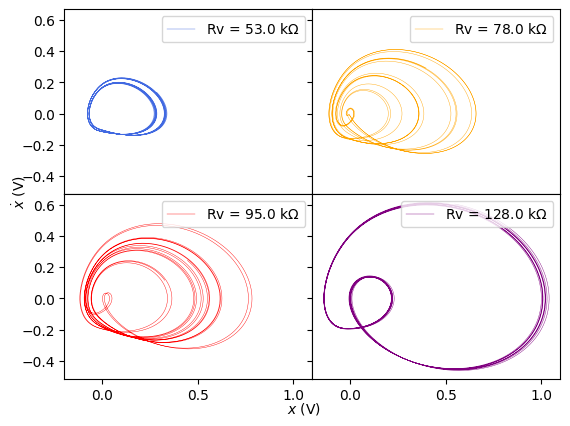

In [14]:
Rv_range = [53.0,78.0,95.0,128.0]
n = len(Rv_range)

V = [[] for i in range(n)]

fig, ax = plt.subplots(2,2,sharex=True,sharey=True)

ax_list = list(ax.flat)

for i in range(len(ax.flat)):
    data = np.loadtxt(f"../Data/RV{Rv_range[i]}.txt")
    t,x,_,Rv = mf.rk4(Rv=Rv_range[i])
    V[i].append(x[half:,0])
    V[i].append(x[half:,1])
    ax_list[i].plot(V[i][0],V[i][1],c=color[i],label=rf'Rv = {Rv_range[i]} k$\Omega$',alpha=1,linewidth=0.3)
    ax_list[i].legend(loc='upper right')

fig.subplots_adjust(hspace=0,wspace=0)
fig.text(0.5, 0.04, r'$x$ (V)', ha='center')
fig.text(0.04, 0.5, r'$\dot{x}$ (V)', va='center', rotation='vertical')

plt.savefig('../Model_Figures/static_figures/phase_spaces',bbox_inches = 'tight')
plt.show()

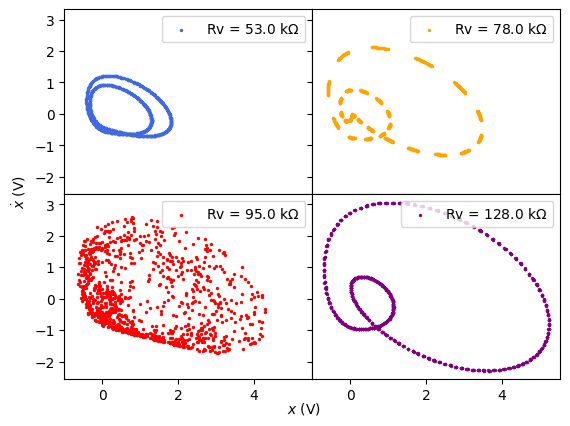

In [15]:
Rv_range = [53.0,78.0,95.0,128.0]
n = len(Rv_range)

t = np.linspace(0,10,2001) / scale_factor
half = len(t) // 2

V = [[] for i in range(n)]

fig, ax = plt.subplots(2,2,sharex=True,sharey=True)

ax_list = list(ax.flat)

for i in range(len(ax.flat)):
    data = np.loadtxt(f'../Data/RV{Rv_range[i]}.txt')
    V[i].append(data[half:,1])
    V[i].append(-data[half:,2])
    ax_list[i].scatter(V[i][0],V[i][1],c=color[i],label=rf'Rv = {Rv_range[i]} k$\Omega$',alpha=1,s=2)
    ax_list[i].legend(loc='upper right')

fig.subplots_adjust(hspace=0,wspace=0)
fig.text(0.5, 0.04, r'$x$ (V)', ha='center')
fig.text(0.04, 0.5, r'$\dot{x}$ (V)', va='center', rotation='vertical')

plt.savefig('../Experimental_results/phase_spaces',bbox_inches = 'tight')
plt.show()

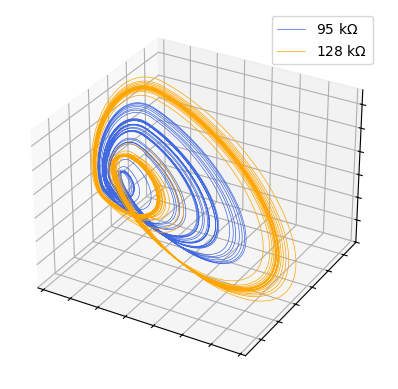

In [26]:
t,x,_, Rv = mf.rk4(Rv=95)
t,y,_, Rv = mf.rk4(Rv=128)

ax = plt.figure().add_subplot(projection='3d')

ax.plot(x[half:,0],x[half:,1],x[half:,2], lw=0.5,color='royalblue',label=r'95 k$\Omega$')
ax.plot(y[half:,0],y[half:,1],y[half:,2], lw=0.5,color='orange',label=r'128 k$\Omega$')

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

ax.legend(loc='upper right')

plt.savefig('../Model_Figures/static_figures/phase_spaces3d',bbox_inches = 'tight')
plt.show()

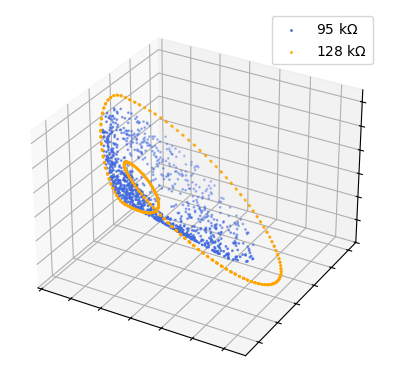

In [25]:
data = np.loadtxt("../Data/RV95.0.txt")
data1 = np.loadtxt("../Data/RV128.0.txt")

t = np.linspace(0,10,2001)
half = len(t) // 2

ax = plt.figure().add_subplot(projection='3d')

ax.scatter(data[half:,1],-data[half:,2],data[half:,3],color='royalblue',s=1,label=r'95 k$\Omega$')
ax.scatter(data1[half:,1],-data1[half:,2],data1[half:,3],color='orange',s=1,label=r'128 k$\Omega$')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

ax.legend(loc='upper right')

plt.savefig('../Experimental_results/phase_spaces3d',bbox_inches = 'tight')
plt.show()

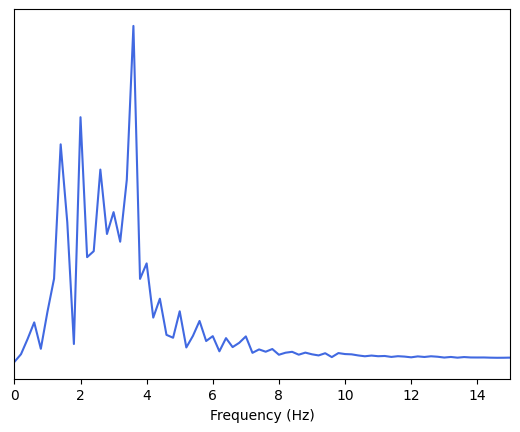

In [7]:
## FFT code
Rv = 95.0
data = np.loadtxt(f"../Data/RV{Rv}.txt")
t, x, _,Rv = mf.rk4(Rv=Rv)
result = x[half:,0]

result = result - np.mean(result)

dt = t[1] - t[0]
fs = 1/dt

fft = np.fft.rfft(result)

fftfreq = np.fft.rfftfreq(len(result), dt)

plt.plot(fftfreq,np.abs(fft),c='royalblue')
plt.xlim(0,15)
plt.xlabel('Frequency (Hz)')
plt.yticks([])

plt.show()

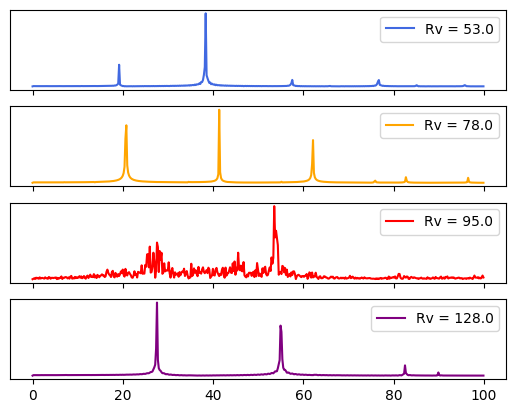

In [72]:
## FFT code
t = np.linspace(0,10,2001)
half = len(t) // 2
dt = t[1] - t[0]

Rv_range = [53.0,78.0,95.0,128.0]
n = len(Rv_range)

fig, axes = plt.subplots(n,1,sharex=True)
plt.setp(axes,label='Frequency (Hz)', yticks= [])
for i in range(n):
    data = np.loadtxt(f"../Data/RV{Rv_range[i]}.txt")
    t = data[half:,0] / scale_factor
    result = data[half:,1]

    result = result - np.mean(result)

    fft = np.fft.rfft(result)

    fftfreq = np.fft.rfftfreq(len(result), dt)
    axes[i].plot(fftfreq,np.abs(fft),c=color[i],label=f'Rv = {Rv_range[i]}')
    axes[i].legend(loc='upper right')
plt.savefig('../Experimental_results/comparefft',bbox_inches = 'tight')
plt.show()

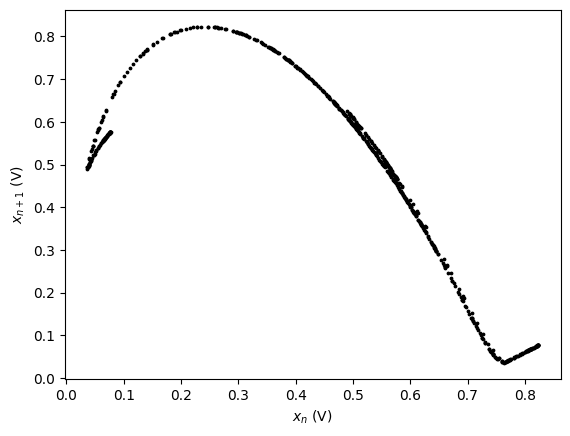

In [3]:
t, x, _,Rv = mf.rk4(Rv=95)
voltages = x[half:,0]
peaks, _ = sig.find_peaks(voltages)
x_peaks = voltages[peaks]

plt.scatter(x_peaks[:-1], x_peaks[1:], s=3, color='black')
plt.xlabel(r"$x_n$ (V)")
plt.ylabel(r"$x_{n+1}$ (V)")
plt.savefig('../Model_Figures/static_figures/rmap_x_V1',bbox_inches = 'tight')
plt.show()

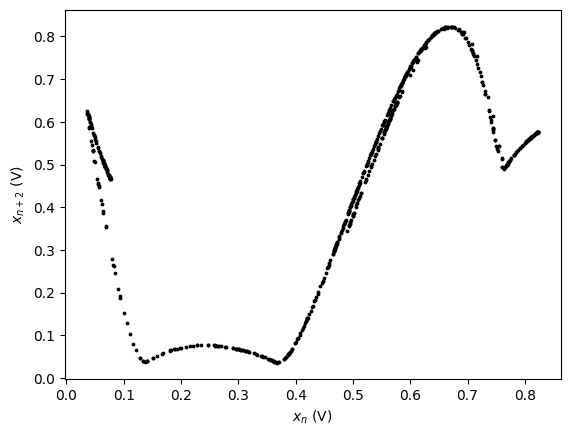

In [4]:
t, x, _,Rv = mf.rk4(Rv=95)
voltages = x[half:,0]
peaks, _ = sig.find_peaks(voltages)
x_peaks = voltages[peaks]

plt.scatter(x_peaks[:-2], x_peaks[2:], s=3, color='black')
plt.xlabel(r"$x_n$ (V)")
plt.ylabel(r"$x_{n+2}$ (V)")
plt.savefig('../Model_Figures/static_figures/rmap_x_V2',bbox_inches = 'tight')
plt.show()

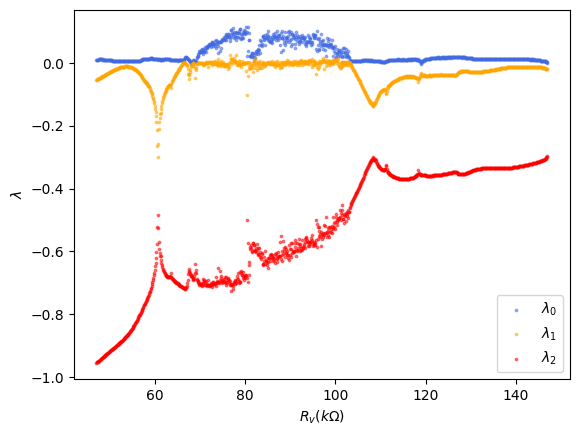

In [32]:
n = 1000
Rv_range = np.linspace(47,147,n)

lambdas_array = np.zeros((n,3))

for j,Rv in enumerate(Rv_range):
    t,x,lambdas,_ = mf.rk4(Rv=Rv)
    lambdas_array[j,:] = lambdas

for i in range(3):
    plt.scatter(Rv_range,lambdas_array[:,i],s=3,color=color[i],alpha=0.5,label=rf"$\lambda_{i}$")
plt.xlabel(r'$R_v(k\Omega)$')
plt.ylabel(r"$\lambda$")
plt.savefig('../Model_Figures/static_figures/lyapunov_exponents',bbox_inches = 'tight')
plt.legend()

In [27]:
data = np.loadtxt("../Data/RV95.0.txt")
exponent = nolds.lyap_r(data[:,1])
print(exponent)


0.07885689135650997


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/nolds/measures.py:31: RuntimeWarning: fitting mode 'RANSAC' requires the package sklearn, using 'poly' instead
  warnings.warn(


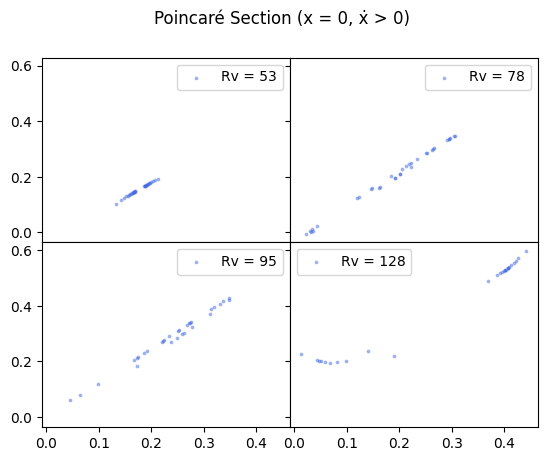

In [12]:
def poincare_crossings(Rv):
    t, x, _, Rv = mf.rk4(Rv=Rv)

    x0 = 0.0  

    indices = np.where((x[:-1, 0] - x0) * (x[1:, 0] - x0) < 0)[0]

    vel_mid = 0.5 * (x[indices, 1] + x[indices + 1, 1])
    crossings = indices[vel_mid > 0] 

    poincare_points = np.empty((len(crossings), 2))
    for j, i in enumerate(crossings):
        frac = (x0 - x[i, 0]) / (x[i + 1, 0] - x[i, 0])
        y_cross = x[i, 1] + frac * (x[i + 1, 1] - x[i, 1])  
        z_cross = x[i, 2] + frac * (x[i + 1, 2] - x[i, 2])  
        poincare_points[j, 0] = y_cross
        poincare_points[j, 1] = z_cross
    return poincare_points

fig, ax = plt.subplots(2,2,sharex=True,sharey=True)
Rv_range = np.array([[53, 78], 
                    [95, 128]])
for i in range(2):
    for j in range(2):
        poincare_points = poincare_crossings(Rv=Rv_range[i,j])
        ax[i,j].scatter(poincare_points[:, 0], poincare_points[:, 1], s=3, alpha=0.4,label=f"Rv = {Rv_range[i,j]}",color=color[0])
        ax[i,j].legend() 
fig.subplots_adjust(hspace=0,wspace=0)
plt.suptitle("Poincaré Section (x = 0, ẋ > 0)")
plt.savefig('../Model_Figures/static_figures/poincare_section',bbox_inches = 'tight')
plt.show()

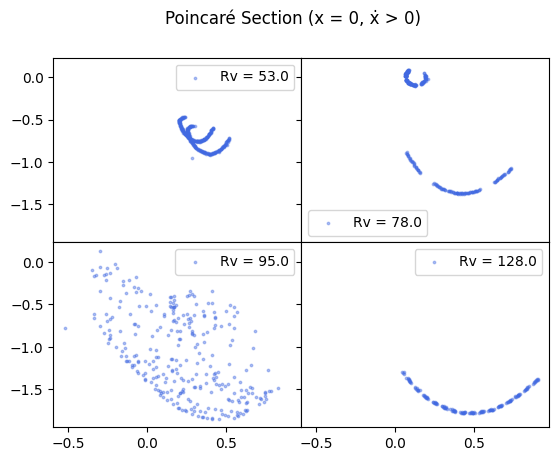

In [11]:
def poincare_crossings(Rv):
    data = np.loadtxt(f"../Data/RV{Rv}.txt")
    x = data[:,1:4]

    x0 = 0.0  

    indices = np.where((x[:-1, 0] - x0) * (x[1:, 0] - x0) < 0)[0]

    vel_mid = 0.5 * (x[indices, 1] + x[indices + 1, 1])
    crossings = indices[vel_mid > 0] 

    poincare_points = np.empty((len(crossings), 2))
    for j, i in enumerate(crossings):
        frac = (x0 - x[i, 0]) / (x[i + 1, 0] - x[i, 0])
        y_cross = x[i, 1] + frac * (x[i + 1, 1] - x[i, 1])  
        z_cross = x[i, 2] + frac * (x[i + 1, 2] - x[i, 2])  
        poincare_points[j, 0] = y_cross
        poincare_points[j, 1] = z_cross
    return poincare_points

fig, ax = plt.subplots(2,2,sharex=True,sharey=True)
Rv_range = np.array([[53.0, 78.0], 
                    [95.0, 128.0]])
for i in range(2):
    for j in range(2):
        poincare_points = poincare_crossings(Rv=Rv_range[i,j])
        ax[i,j].scatter(poincare_points[:, 0], -poincare_points[:, 1], s=3, alpha=0.4,label=f"Rv = {Rv_range[i,j]}",color=color[0])
        ax[i,j].legend() 
fig.subplots_adjust(hspace=0,wspace=0)
plt.suptitle("Poincaré Section (x = 0, ẋ > 0)")
plt.savefig('../Experimental_results/poincare_section',bbox_inches = 'tight')
plt.show()

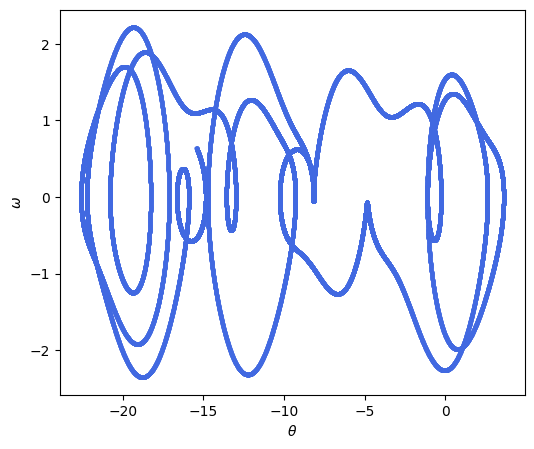

In [ ]:
q = 2
g = 1.2
omega_D = 2/3

t, f = mf.rk4_pendulum(q, omega_D, g)

plt.figure(figsize=(6,5))
plt.scatter(f[half:,1], f[half:,0], s=4, c=color[0], alpha=0.7)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\omega$")
plt.savefig('../Model_Figures/static_figures/pendulum_chaotic_phase_space',bbox_inches = 'tight')
plt.show()

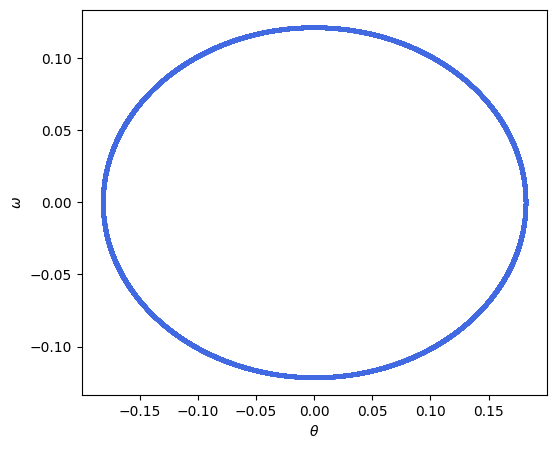

In [ ]:
q = 0.7
g = 0.2
omega_D = 2/3

t, f = mf.rk4_pendulum(q, omega_D, g)

plt.figure(figsize=(6,5))
plt.scatter(f[half:,1], f[half:,0], s=4, c=color[0], alpha=0.7)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\omega$")
plt.savefig('../Model_Figures/static_figures/pendulum_nonchaotic_phase_space',bbox_inches = 'tight')
plt.show()

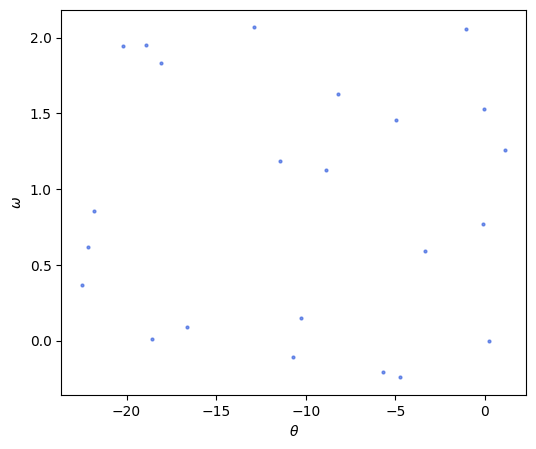

In [ ]:
q = 2
g = 1.2
omega_D = 2/3

t, f = mf.rk4_pendulum(q, omega_D, g)

T_D = 2*np.pi / omega_D
sample_times = np.arange(0, t[-1], T_D)

theta = np.interp(sample_times, t, f[:, 1])
omega = np.interp(sample_times, t, f[:, 0])

plt.figure(figsize=(6,5))
plt.scatter(theta, omega, s=4, c=color[0], alpha=0.7)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\omega$")
plt.savefig('../Model_Figures/static_figures/pendulum_chaotic_poincare_section',bbox_inches = 'tight')
plt.show()


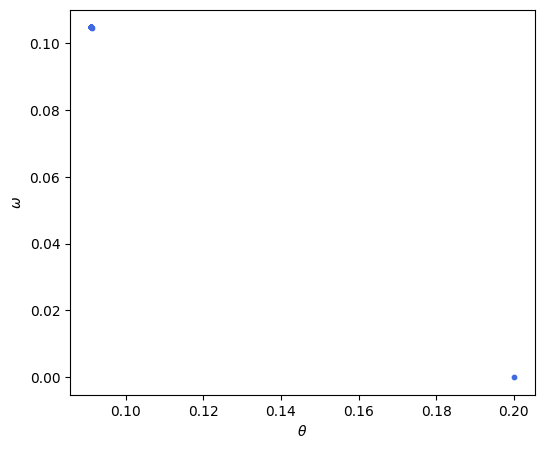

In [7]:
q = 0.7
g = 0.2
omega_D = 2/3

t, f = mf.rk4_pendulum(q, omega_D, g)

T_D = 2*np.pi / omega_D
sample_times = np.arange(0, t[-1], T_D)

theta = np.interp(sample_times, t, f[:, 1])
omega = np.interp(sample_times, t, f[:, 0])

plt.figure(figsize=(6,5))
plt.scatter(theta, omega, s=10, c=color[0], alpha=1)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\omega$")
plt.savefig('../Model_Figures/static_figures/pendulum_nonchaotic_poincare_section',bbox_inches = 'tight')
plt.show()


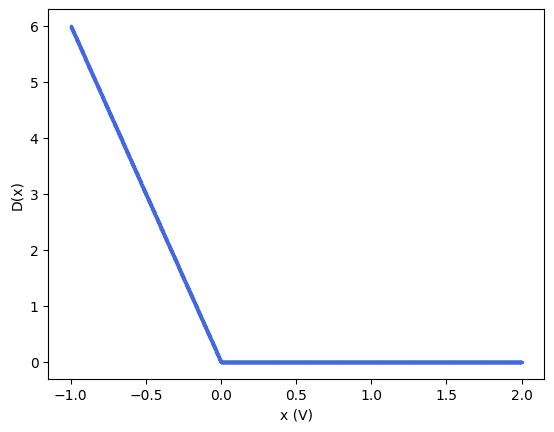

In [25]:
def D(x):
    result = []
    for i in x:
        if i < 0:
            i = i * -6
            result.append(i)
        else:
            result.append(0)
    return result

x = np.linspace(-1,2,3001)

plt.scatter(x,D(x),c='royalblue',s=2)
plt.xlabel('x (V)')
plt.ylabel("D(x)")
plt.savefig('../Model_Figures/static_figures/non_linear',bbox_inches = 'tight')
plt.show()